# 使用双重深度Q网络(DDQN)解决MountainCar问题

## 问题介绍

### Mountain Car问题
Mountain Car（小车上山）是强化学习领域一个经典的测试环境。其核心挑战在于，一辆动力不足的小车需要在一个U型山谷中，通过前后往复的策略性移动，积累足够的动能，最终成功爬上右侧的山顶。

**问题设定:**
- 状态空间 (State Space): 这是一个连续的二维空间，由小车的位置（通常在 [-1.2, 0.6] 的区间内）和速度（通常在 [-0.07, 0.07] 的区间内）共同定义。
- 动作空间 (Action Space): 动作空间是离散的，通常包含三个动作：向左施加推力 (-1)、不施加推力 (0)、向右施加推力 (+1)。
- 奖励机制 (Reward Structure): 该问题的奖励机制具有稀疏性。在绝大多数情况下，小车在每个时间步都会收到一个负奖励（例如 -1），以激励其尽快到达终点。只有当小车成功到达山顶（位置 > 0.5）时，才会获得一个较大的正奖励（例如 0 或更高）。

**核心挑战:** 小车发动机的功率不足以直接从谷底爬上山坡。因此，智能体必须学会一个“迂回”策略：先向远离目标的一侧（左侧山坡）加速，利用下坡的势能转化为动能，再反向加速冲向右侧的山顶。

### 深度Q网络(DQN)

在处理像Mountain Car这样具有连续状态空间的问题时，传统的Q-Learning方法由于无法维护一个覆盖所有状态-动作对的Q表而变得不切实际。深度Q网络 (DQN) 的出现，巧妙地解决了这一难题。

DQN的核心思想是使用一个深度神经网络来近似Q函数 (Q(s,a;θ))，其中 s 是状态， a 是动作，θ 是神经网络的参数。输入网络的是环境的状态（例如小车的位置和速度），输出则是该状态下每个可能动作的Q值。

**DQN的关键技术:**

1. **经验回放 (Experience Replay):** 为了打破数据之间的相关性并提高数据利用率，DQN引入了一个经验回放池。智能体在与环境交互过程中产生的样本（(状态, 动作, 奖励, 下一状态) 的元组）会被存储起来。在训练时，算法会从这个池中随机抽取一小批（mini-batch）样本进行学习，这有助于稳定训练过程。

2. **目标网络 (Target Network):** 为了解决Q值更新目标（TD Target）与正在更新的Q值网络之间的耦合问题，DQN使用了两个网络：

- 策略网络 (Policy Network) / 在线网络 (Online Network): 用于在当前状态下选择动作，并且其参数在每个训练步都会更新。

- 目标网络 (Target Network): 用于计算TD Target。它的网络结构与策略网络完全相同，但其参数并不会实时更新，而是每隔一定数量的训练步才从策略网络中复制一次。这大大增加了训练的稳定性。

### 双重深度Q网络(DDQN)

尽管DQN取得了巨大成功，但它存在一个固有的问题：Q值过高估计 (Overestimation of Q-values)。在选择和评估下一个状态的最佳动作时，DQN都使用了同一个目标网络。如果目标网络对某个动作的Q值产生了正向的估计误差，max 操作符很可能会选择这个被高估的动作，从而导致TD Target偏高，并将这种偏差传播到整个学习过程中。

**DDQN的核心改进**

DDQN巧妙地将动作选择和价值评估这两个过程解耦，分别由两个不同的网络来完成。

**动作选择:** 使用当前的策略网络（在线网络）来选择在下一状态 s 
t+1下能够获得最高Q值的动作 $a^*$

**价值评估:**使用目标网络来评估这个被策略网络选中的动作 $a^*$ 的价值。

通过这种方式，即使策略网络由于随机误差高估了某个动作，只要目标网络没有同样高估该动作，最终的TD Target就会更加接近真实值，从而有效缓解了Q值的过高估计问题。


---
下面是使用DDQN训练智能体解决mountain car问题的过程以及与使用DQN实现的结果分析

## 导入需要的库

In [1]:
%matplotlib inline
import gymnasium as gym  # 导入强化学习环境库
import numpy as np  # 导入数值计算库
import matplotlib.pyplot as plt  # 导入绘图库
from collections import deque  # 导入双端队列，用于实现经验回放池
import random  # 导入随机库，用于epsilon-greedy策略
import torch  # 导入PyTorch深度学习框架
from torch import nn  # 导入PyTorch神经网络模块
import torch.nn.functional as F  # 导入PyTorch神经网络函数
import os  # 导入操作系统库，用于检查文件是否存在
from tqdm import tqdm  # 导入进度条库，用于可视化训练进程

# --- 全局设置：解决 Matplotlib 中文显示问题 ---
plt.rcParams['font.sans-serif'] = ['SimHei']  # 指定默认字体为黑体
plt.rcParams['axes.unicode_minus'] = False  # 解决保存图像是负号'-'显示为方块的问题

# 设置随机种子以保证结果可复现 ---
SEED = 42  # seed-42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED) # if you are using multi-GPU.
    # 下面两行是为了保证在CUDA下的计算结果是确定的，但可能会牺牲一些性能
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

## 第1步: 定义神经网络 (DQN Model)
DQN算法的核心是使用一个神经网络来近似Q函数 Q(s, a)。这个网络接收当前的状态 s 作为输入，输出每个可能动作 a 的Q值。
DDQN同样使用神经网络来近似Q函数。网络结构与DQN相同。
网络结构:
- 输入层: 神经元数量等于状态空间的维度 (对于MountainCar是2: 位置和速度)。
- 隐藏层: 使用两个全连接的隐藏层，每层有64个神经元，并使用ReLU作为激活函数。这能让网络学习更复杂的非线性关系。
- 输出层: 神经元数量等于动作空间的数量 (对于MountainCar是3: 向左、不动、向右)。

In [2]:
class DQN(nn.Module):  # 定义一个继承自 nn.Module 的类
    """DDQN"""
    def __init__(self, in_states, h1_nodes, out_actions):  # 类的初始化函数
        super().__init__()  # 调用父类的初始化函数

        # --- 定义网络层 ---
        self.fc1 = nn.Linear(in_states, h1_nodes)  # 第一个全连接层 (输入层 -> 隐藏层1)
        self.fc2 = nn.Linear(h1_nodes, h1_nodes)  # 第二个全连接层 (隐藏层1 -> 隐藏层2)
        self.out = nn.Linear(h1_nodes, out_actions)  # 输出层 (隐藏层2 -> 输出层)

    def forward(self, x):  # 定义网络的前向传播过程
        x = F.relu(self.fc1(x))  # 应用ReLU激活函数到第一个隐藏层
        x = F.relu(self.fc2(x))  # 应用ReLU激活函数到第二个隐藏层
        x = self.out(x)  # 计算最终输出
        return x  # 返回输出的Q值

## 第2步: 定义经验回放池 (Replay Memory)
为了打破训练数据之间的时间相关性并提高数据利用率，我们使用经验回放池。
工作原理:
1. 智能体与环境交互，产生一条经验（state, action, reward, next_state, terminated）。
2. 将这条经验存入一个固定大小的缓冲区（我们使用deque）。
3. 当缓冲区满了之后，新的经验会挤掉最旧的经验。
4. 在训练时，从缓冲区中随机采样一小批经验来进行学习，而不是使用刚刚产生的数据。

In [3]:
class ReplayMemory():  # 定义经验回放池类
    """经验回放缓冲区，用于存储和采样经验"""
    def __init__(self, maxlen):  # 初始化函数，maxlen是缓冲区的最大容量
        # 使用 collections.deque 创建一个双端队列，maxlen参数会自动管理队列大小
        self.memory = deque([], maxlen=maxlen)

    def append(self, transition):  # 定义添加经验的方法
        self.memory.append(transition)  # 将一条经验（一个元组）添加到队列末尾

    def sample(self, sample_size):  # 定义采样方法
        # 使用 random.sample 从内存中随机抽取指定数量的经验
        return random.sample(self.memory, sample_size)

    def __len__(self):  # 定义获取当前存储经验数量的方法
        return len(self.memory)  # 返回队列的当前长度

## 第3步: 定义DDQN智能体 (MountainCarDDQN Class)
负责初始化网络、管理训练循环、执行优化步骤、评估性能以及与环境交互。
这个类包含了几个重要的方法：
- train(): 主训练循环，负责迭代多个回合（episodes）。
- optimize(): 执行一步网络优化，计算损失并更新网络权重。
- state_to_tensor(): 一个辅助函数，将环境的状态转换为PyTorch张量。
- analyze_and_report(): 训练结束后，计算并打印最终的性能指标。
- plot_progress(): 绘制训练曲线图。
- test(): 使用训练好的模型进行可视化测试。

In [4]:
class MountainCarDDQN():
    # --- 超参数定义 ---
    LEARNING_RATE = 0.0005
    DISCOUNT_FACTOR = 0.99
    NETWORK_SYNC_RATE = 1000
    REPLAY_MEMORY_SIZE = 50000
    MINI_BATCH_SIZE = 128
    
    # --- Epsilon (探索率) 相关参数 ---
    EPSILON_START = 1.0
    EPSILON_END = 0.01
    EPSILON_DECAY_LAST_EPISODE = 0.8

    # --- 神经网络相关定义 ---
    loss_fn = nn.SmoothL1Loss()
    optimizer = None

    def state_to_tensor(self, state) -> torch.Tensor:
        """将Numpy状态数组转换为PyTorch浮点型张量"""
        return torch.tensor(state, dtype=torch.float32)

    def optimize(self, mini_batch, policy_dqn, target_dqn, device):
        """
        使用小批量数据优化策略网络。
        这是DDQN与DQN最关键的区别所在。
        """
        # --- 1. 数据准备 ---
        states, actions, next_states, rewards, terminated_flags = zip(*mini_batch)
        
        states = torch.stack([self.state_to_tensor(s) for s in states]).to(device)
        actions = torch.tensor(actions, dtype=torch.int64).view(-1, 1).to(device)
        next_states = torch.stack([self.state_to_tensor(s) for s in next_states]).to(device)
        rewards = torch.tensor(rewards, dtype=torch.float32).view(-1, 1).to(device)
        terminated_flags = torch.tensor(terminated_flags, dtype=torch.float32).view(-1, 1).to(device)

        # --- 2. 计算当前Q值 ---
        # Q(s, a; θ): 使用策略网络计算当前状态下，实际所采取动作的Q值
        current_q = policy_dqn(states).gather(1, actions)

        # --- 3. 计算目标Q值 (Target Q) - DDQN的核心改动 ---
        # y = r + γ * Q_target(s', argmax_a' Q_policy(s', a'; θ_policy); θ_target)
        with torch.no_grad():
            # a'. 使用策略网络(policy_dqn)为下一个状态(next_states)选择最佳动作
            # .max(1)[1] 返回最大Q值对应的索引（即动作）
            next_state_actions = policy_dqn(next_states).max(1)[1].unsqueeze(1)
            
            # b. 使用目标网络(target_dqn)评估这些由策略网络选出的动作的Q值
            # .gather(1, next_state_actions) 从目标网络中提取出对应动作的Q值
            next_q_values = target_dqn(next_states).gather(1, next_state_actions)

            # c. 计算最终的目标Q值。如果是终止状态，未来奖励为0。
            target_q = rewards + (1 - terminated_flags) * self.DISCOUNT_FACTOR * next_q_values

        # --- 4. 计算损失并优化 ---
        loss = self.loss_fn(current_q, target_q)
        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(policy_dqn.parameters(), max_norm=1.0)
        self.optimizer.step()

    def train(self, episodes, render=False):
        """执行完整的训练过程"""
        # --- 初始化 ---
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        print(f"训练设备: {device}")

        env = gym.make('MountainCar-v0', render_mode='human' if render else None)
        num_states = env.observation_space.shape[0]
        num_actions = env.action_space.n
        
        self.epsilon_decay = (self.EPSILON_START - self.EPSILON_END) / (episodes * self.EPSILON_DECAY_LAST_EPISODE)
        epsilon = self.EPSILON_START
        
        memory = ReplayMemory(self.REPLAY_MEMORY_SIZE)

        policy_dqn = DQN(in_states=num_states, h1_nodes=64, out_actions=num_actions).to(device)
        target_dqn = DQN(in_states=num_states, h1_nodes=64, out_actions=num_actions).to(device)
        target_dqn.load_state_dict(policy_dqn.state_dict())
        target_dqn.eval()
        
        self.optimizer = torch.optim.Adam(policy_dqn.parameters(), lr=self.LEARNING_RATE)
        scheduler = torch.optim.lr_scheduler.StepLR(self.optimizer, step_size=500, gamma=0.5)

        # --- 用于追踪性能的变量 ---
        rewards_per_episode = []
        moving_avg_rewards = []
        step_count = 0
        best_moving_avg_reward = -float('inf')
        
        # --- 用于评估收敛的变量 ---
        convergence_threshold = -110.0
        convergence_episode = None
        MIN_EPISODES_FOR_CONVERGENCE_CHECK = 100

        print("开始训练...")
        # --- 主训练循环 ---
        for i in tqdm(range(episodes), desc="训练进度"):
            state, _ = env.reset()
            terminated, truncated = False, False
            episode_rewards = 0.0

            # --- 单回合循环 ---
            while not terminated and not truncated:
                # Epsilon-greedy 动作选择
                if random.random() < epsilon:
                    action = env.action_space.sample()
                else:
                    with torch.no_grad():
                        state_tensor = self.state_to_tensor(state).unsqueeze(0).to(device)
                        action = policy_dqn(state_tensor).argmax().item()

                # 与环境交互
                new_state, reward, terminated, truncated, _ = env.step(action)
                
                # 奖励塑造 (Reward Shaping)
                shaped_reward = 10 * (np.sin(3 * new_state[0]) - np.sin(3 * state[0]))
                total_reward = reward + shaped_reward
                
                episode_rewards += total_reward

                # 存储经验
                memory.append((state, action, new_state, total_reward, terminated))
                state = new_state
                step_count += 1

                # 如果经验足够，则进行优化
                if len(memory) > self.MINI_BATCH_SIZE:
                    mini_batch = memory.sample(self.MINI_BATCH_SIZE)
                    self.optimize(mini_batch, policy_dqn, target_dqn, device)

                # 定期同步目标网络
                if step_count % self.NETWORK_SYNC_RATE == 0:
                    target_dqn.load_state_dict(policy_dqn.state_dict())

            # 更新学习率
            scheduler.step()

            # --- 回合结束后的处理 ---
            rewards_per_episode.append(episode_rewards)
            moving_avg_rewards.append(np.mean(rewards_per_episode[-100:]))
            
            # 判断是否收敛
            if i >= MIN_EPISODES_FOR_CONVERGENCE_CHECK:
                current_moving_avg = moving_avg_rewards[-1]
                if convergence_episode is None and current_moving_avg > convergence_threshold:
                    convergence_episode = i + 1
                    print(f"\n智能体在第 {convergence_episode} 回合达到收敛标准 (平均奖励 > {convergence_threshold})！")

            # 保存性能最好的模型
            current_moving_avg_for_save = moving_avg_rewards[-1]
            if current_moving_avg_for_save > best_moving_avg_reward:
                best_moving_avg_reward = current_moving_avg_for_save
                torch.save(policy_dqn.state_dict(), "mountaincar_ddqn_best.pt")

            # Epsilon 衰减
            epsilon = max(self.EPSILON_END, epsilon - self.epsilon_decay)
        
        print("训练完成。")
        env.close()

        # --- 训练结束后进行分析和绘图 ---
        self.analyze_and_report(rewards_per_episode, moving_avg_rewards, convergence_episode, episodes)
        self.plot_progress(rewards_per_episode, moving_avg_rewards)

    def analyze_and_report(self, rewards_per_episode, moving_avg_rewards, convergence_episode, total_episodes):
        """计算并打印最终的性能指标"""
        print("\n--- 训练性能分析 ---")

        # 1. 平均奖励值 (最终表现)
        final_performance = np.mean(rewards_per_episode[-100:])
        print(f"1. 平均奖励值 (最终表现): {final_performance:.2f}")
        print("   (指标解释: 训练最后100个回合的平均奖励，反映了智能体的最终能力。)")

        # 2. 收敛速度
        if convergence_episode:
            print(f"2. 收敛速度: 在第 {convergence_episode} 回合达到收敛标准。")
        else:
            print("2. 收敛速度: 在训练期间未能达到指定的收敛标准 (-110 平均奖励)。")
        print("   (指标解释: 智能体达到稳定高性能策略所需的回合数。越小越好。)")

        # 3. 稳定性
        if convergence_episode and total_episodes > convergence_episode:
            post_convergence_rewards = rewards_per_episode[convergence_episode:]
            stability = np.std(post_convergence_rewards) if len(post_convergence_rewards) > 0 else 0.0
            print(f"3. 稳定性 (收敛后奖励的标准差): {stability:.2f}")
        else:
            half_point = len(rewards_per_episode) // 2
            stability = np.std(rewards_per_episode[half_point:])
            print(f"3. 稳定性 (后半段训练奖励的标准差): {stability:.2f}")
        print("   (指标解释: 收敛后奖励的波动程度。标准差越小，策略越稳定。)")

    def plot_progress(self, rewards_per_episode, moving_avg_rewards):
        """绘制训练过程图"""
        plt.figure(figsize=(12, 6)) # 创建一个12x6英寸的图
        plt.title('DDQN Training Progress on MountainCar-v0') # 设置图表标题
        plt.xlabel('Episode') # 设置X轴标签
        plt.ylabel('Total Reward') # 设置Y轴标签
        plt.plot(rewards_per_episode, label='Reward per Episode', alpha=0.3, color='grey') # 绘制每回合奖励（半透明）
        plt.plot(moving_avg_rewards, label='100-Episode Moving Average', color='blue', linewidth=2) # 绘制移动平均奖励
        plt.axhline(y=-110, color='r', linestyle='--', label='Solved Threshold (-110)') # 绘制-110的解决标准线
        plt.legend() # 显示图例
        plt.grid(True) # 显示网格
        plt.show() # 显示图表

    def test(self, episodes, model_filepath):
        """使用训练好的模型进行可视化测试"""
        if not os.path.exists(model_filepath):
            print(f"错误: 找不到模型文件 '{model_filepath}'。请先训练模型。")
            return

        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        print(f"\n测试设备: {device}")

        env = gym.make('MountainCar-v0', render_mode='human')
        num_states = env.observation_space.shape[0]
        num_actions = env.action_space.n

        policy_dqn = DQN(in_states=num_states, h1_nodes=64, out_actions=num_actions).to(device)
        policy_dqn.load_state_dict(torch.load(model_filepath))
        policy_dqn.eval()

        print(f"开始测试，运行 {episodes} 回合...")
        for i in range(episodes):
            state, _ = env.reset()
            terminated, truncated = False, False
            print(f"--- 测试回合 {i+1} ---")
            
            while not terminated and not truncated:
                with torch.no_grad():
                    state_tensor = self.state_to_tensor(state).unsqueeze(0).to(device)
                    action = policy_dqn(state_tensor).argmax().item()

                state, _, terminated, truncated, _ = env.step(action)
            
            if terminated:
                print("目标已达成！")
            elif truncated:
                print("达到最大步数限制。")

        env.close()

## 第4步: 实例化并开始训练
- 设置一个总的训练回合数 TRAINING_EPISODES。
- 创建 MountainCarDDQN 类的一个实例。
- 调用 train() 方法，启动整个训练过程。

训练过程中的所有信息，包括进度条、收敛报告和最终的性能指标，都会被打印出来。训练结束后，性能曲线图也会被直接绘制在下方。

训练设备: cuda
开始训练...


训练进度:  74%|███████▎  | 1474/2000 [16:32<03:56,  2.23it/s]


智能体在第 1474 回合达到收敛标准 (平均奖励 > -110.0)！


训练进度: 100%|██████████| 2000/2000 [20:40<00:00,  1.61it/s]

训练完成。

--- 训练性能分析 ---
1. 平均奖励值 (最终表现): -92.32
   (指标解释: 训练最后100个回合的平均奖励，反映了智能体的最终能力。)
2. 收敛速度: 在第 1474 回合达到收敛标准。
   (指标解释: 智能体达到稳定高性能策略所需的回合数。越小越好。)
3. 稳定性 (收敛后奖励的标准差): 21.56
   (指标解释: 收敛后奖励的波动程度。标准差越小，策略越稳定。)


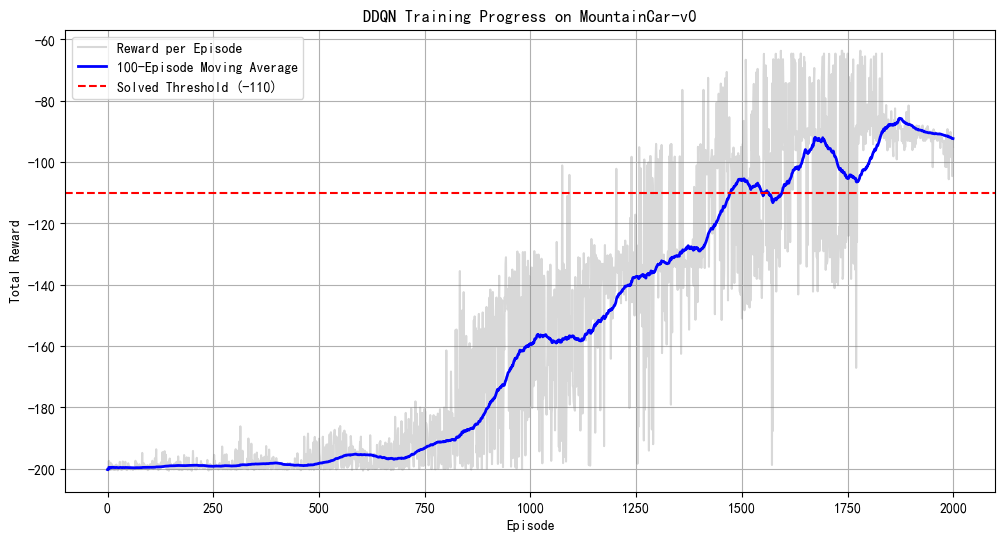

In [5]:
TRAINING_EPISODES = 2000  # 设置总训练回合数

mountaincar_agent = MountainCarDDQN()  # 实例化DQN智能体

# 调用 train 方法，启动训练
mountaincar_agent.train(episodes=TRAINING_EPISODES)

## 第5步: 测试训练好的模型

In [8]:
# 调用 test 方法，使用性能最好的模型进行可视化测试
mountaincar_agent.test(episodes=10, model_filepath="mountaincar_ddqn_best.pt")


测试设备: cuda
开始测试，运行 10 回合...
--- 测试回合 1 ---
目标已达成！
--- 测试回合 2 ---
目标已达成！
--- 测试回合 3 ---
目标已达成！
--- 测试回合 4 ---
目标已达成！
--- 测试回合 5 ---
目标已达成！
--- 测试回合 6 ---
目标已达成！
--- 测试回合 7 ---
目标已达成！
--- 测试回合 8 ---
目标已达成！
--- 测试回合 9 ---
目标已达成！
--- 测试回合 10 ---
目标已达成！


---
## 结果分析
下图是在同样的训练环境与参数下使用DQN进行训练的结果
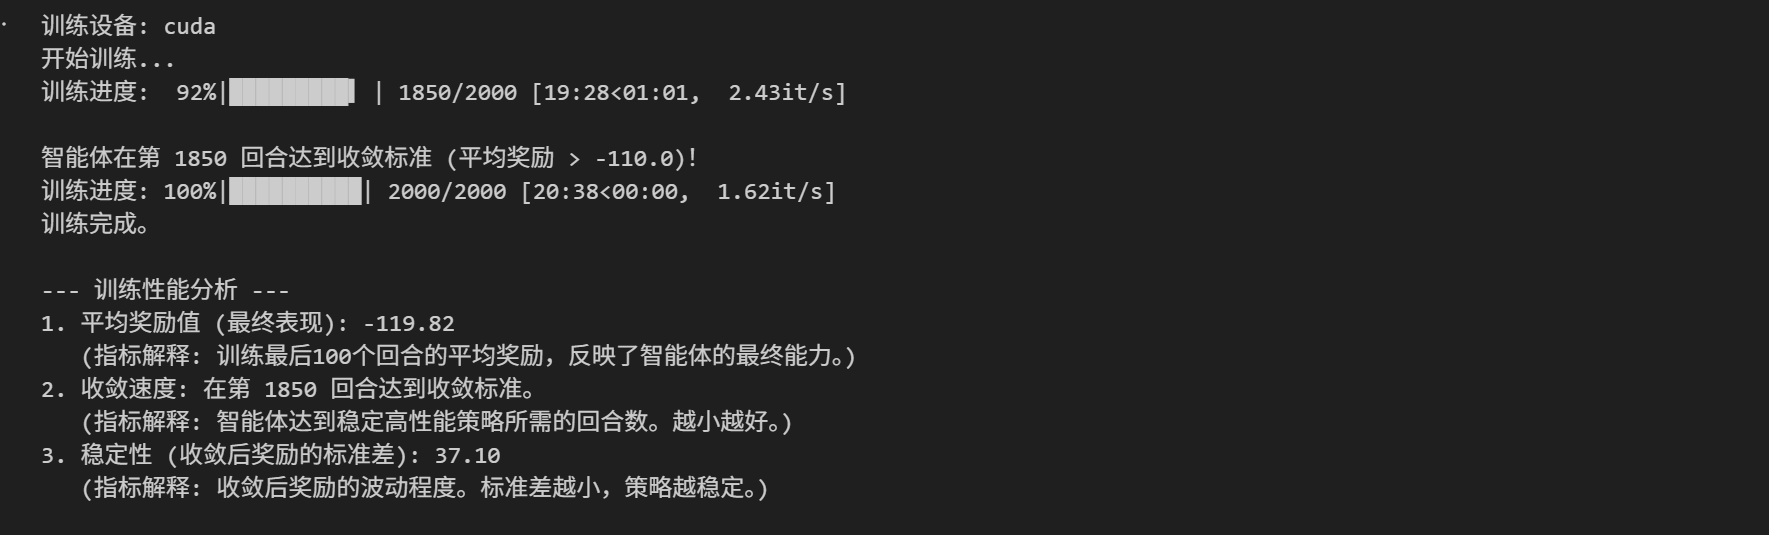
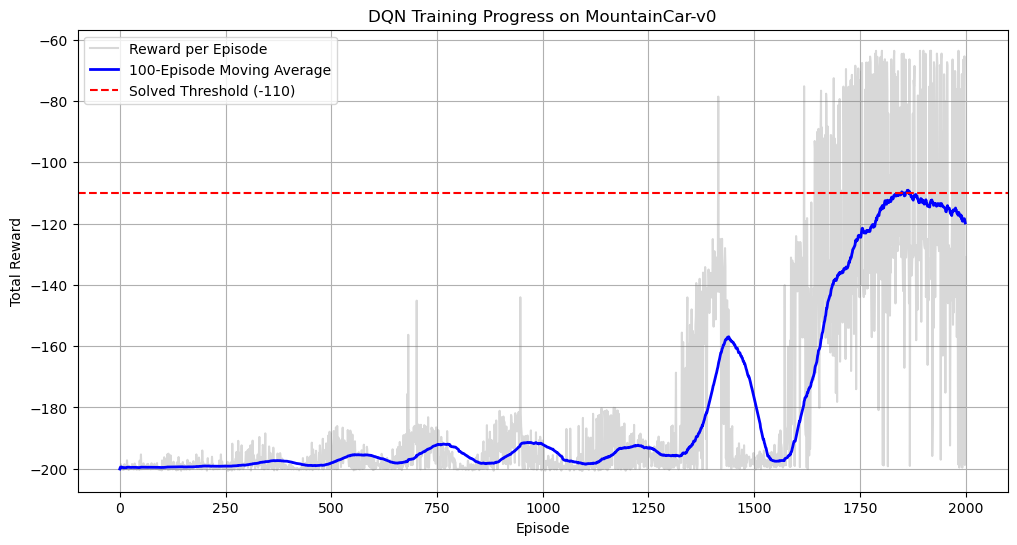
可以看到
1. **平均奖励：** DQN的最后平均奖励值为-119.82而DDQN的最终平均奖励为-92.32显著优于收敛标准并且由于DQN的最终平均奖励。这表明DDQN学习到了一个更有效的策略。
2. **收敛速度：** DQN在1850回合达到收敛标准，所需时间相对较长，而DDQN在1474回合就达到了收敛标准，学习效率更高。
3. **稳定性：** DQN收敛后奖励的标准差为37.10，波动性相对较高，而DDQN收敛后奖励的标准差为21.56比DQN低得多，说明DDQN在收敛后更加稳定。

DQN与DDQN的测试视频如下连接：[DQN与DDQN测试结果](通过网盘分享的文件：DQN&DDQN
链接: https://pan.baidu.com/s/1IGKYNlbce77aPdP-SG_RyA?pwd=kxc6 提取码: kxc6 
--来自百度网盘超级会员v5的分享)
可以看到，虽然两者在10个测试回合内都爬上了右侧的山顶，但是DQN训练出的智能体所用的步数不稳定且更多，而DDQN训练出的智能体稳定的在很少的步数就能爬上右侧的山顶。

---
## 总结
- 通过本项目，我学到了强化学习的基础概念，以及深度学习在强化学习中的应用，当然通过mountain car这个例子我也了解到了强化学习能够解决的问题都有哪些。同时该项目也让我深刻理解了DQN与DDQN这两种算法的核心机制，为未来强化学习在我学习工作中的使用埋下了基础。
- **本人负责此次项目的DQN主体代码以及DDQN优化代码的编写与调试**